# Assignment No.20

In [1]:
!pip install tensorflow -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow version:", tf.__version__)
print("All libraries imported!")

TensorFlow version: 2.21.0
All libraries imported!


In [2]:
df = pd.read_csv('monthly_milk_production.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df.columns = ['Production']

print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nFirst 5 rows:\n", df.head())
print("\nLast 5 rows:\n", df.tail())
print("\nStatistical Summary:\n", df.describe())

Shape: (168, 1)

Data Types:
 Production    int64
dtype: object

First 5 rows:
             Production
Date                  
1962-01-01         589
1962-02-01         561
1962-03-01         640
1962-04-01         656
1962-05-01         727

Last 5 rows:
             Production
Date                  
1975-08-01         858
1975-09-01         817
1975-10-01         827
1975-11-01         797
1975-12-01         843

Statistical Summary:
        Production
count  168.000000
mean   754.708333
std    102.204524
min    553.000000
25%    677.750000
50%    761.000000
75%    824.500000
max    969.000000


In [3]:
print("Missing Values:\n", df.isnull().sum())
print(f"\nTotal rows: {len(df)}")
print(f"Date range: {df.index.min()} to {df.index.max()}")

Q1 = df['Production'].quantile(0.25)
Q3 = df['Production'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['Production'] < Q1 - 1.5 * IQR) | (df['Production'] > Q3 + 1.5 * IQR)]
print(f"\nOutliers detected: {len(outliers)}")
print(outliers)

Missing Values:
 Production    0
dtype: int64

Total rows: 168
Date range: 1962-01-01 00:00:00 to 1975-12-01 00:00:00

Outliers detected: 0
Empty DataFrame
Columns: [Production]
Index: []


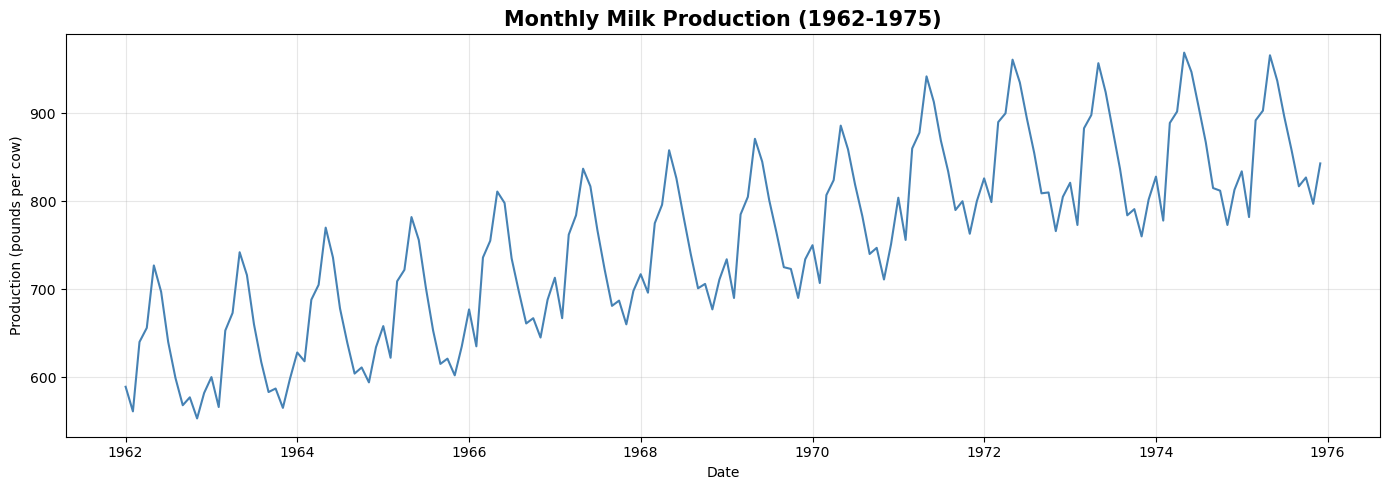

In [4]:
plt.figure(figsize=(14, 5))
plt.plot(df.index, df['Production'], color='steelblue', linewidth=1.5)
plt.title('Monthly Milk Production (1962-1975)', fontsize=15, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Production (pounds per cow)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('milk_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

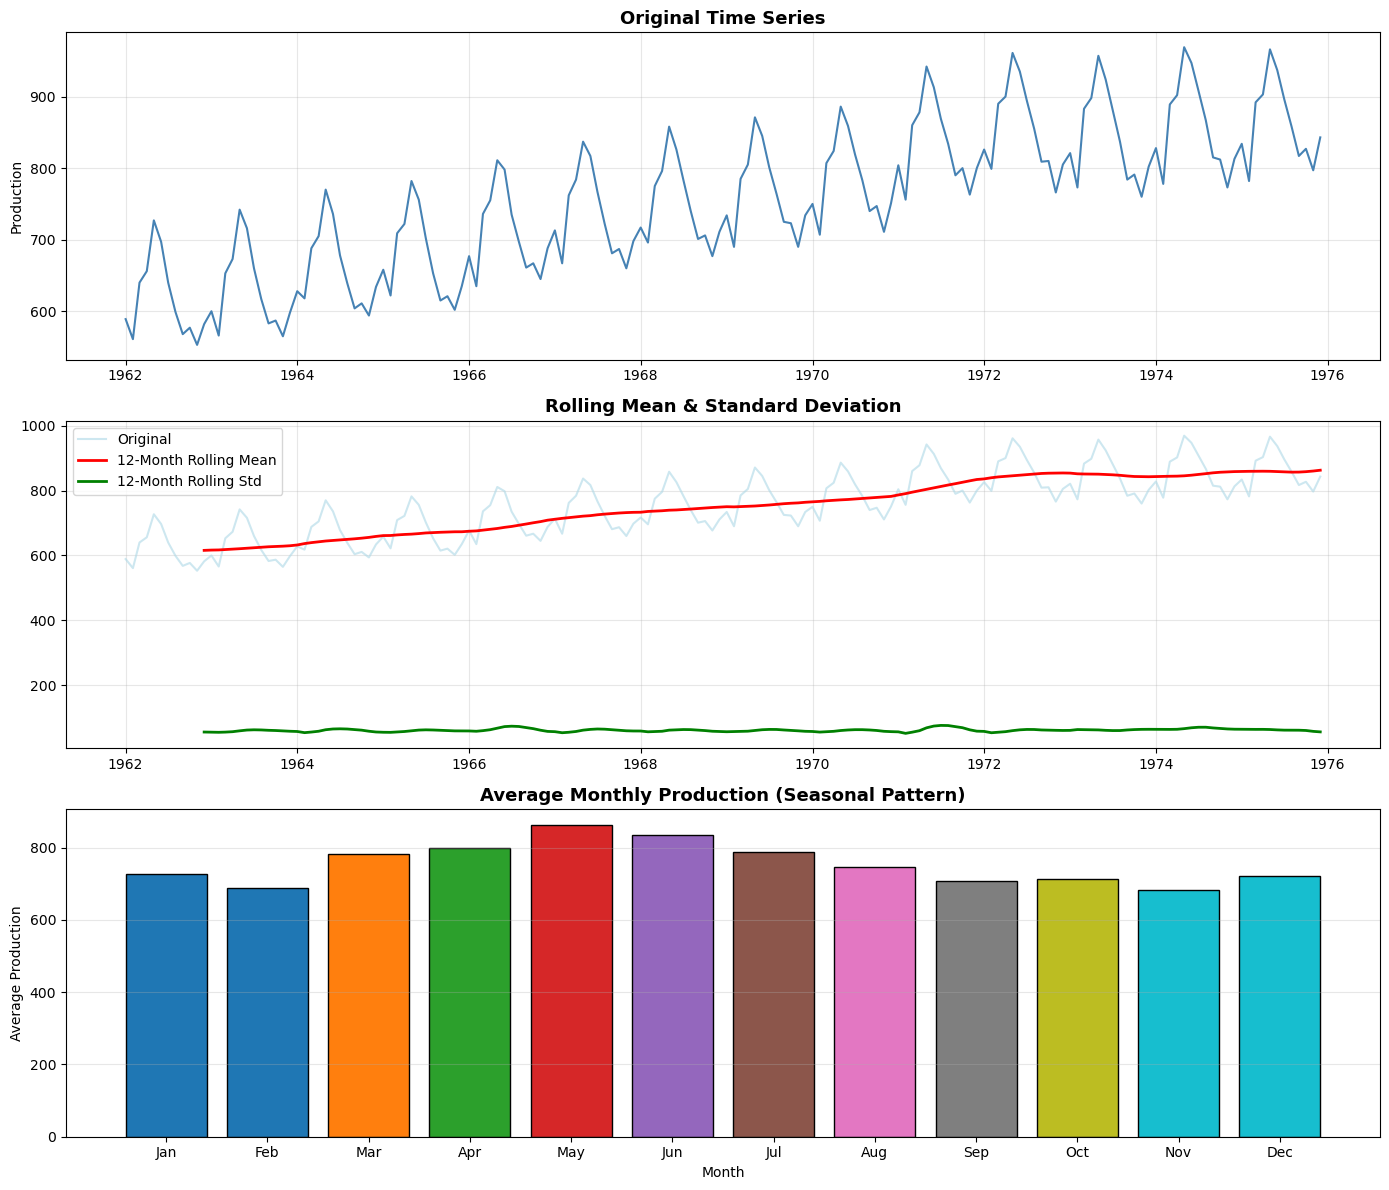

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

axes[0].plot(df.index, df['Production'], color='steelblue', linewidth=1.5)
axes[0].set_title('Original Time Series', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Production')
axes[0].grid(True, alpha=0.3)

rolling_mean = df['Production'].rolling(window=12).mean()
rolling_std  = df['Production'].rolling(window=12).std()
axes[1].plot(df.index, df['Production'], color='lightblue', label='Original', alpha=0.6)
axes[1].plot(df.index, rolling_mean, color='red', label='12-Month Rolling Mean', linewidth=2)
axes[1].plot(df.index, rolling_std, color='green', label='12-Month Rolling Std', linewidth=2)
axes[1].set_title('Rolling Mean & Standard Deviation', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

monthly_avg = df.groupby(df.index.month)['Production'].mean()
axes[2].bar(monthly_avg.index, monthly_avg.values,
            color=plt.cm.tab10(np.linspace(0, 1, 12)), edgecolor='black')
axes[2].set_title('Average Monthly Production (Seasonal Pattern)', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Month')
axes[2].set_ylabel('Average Production')
axes[2].set_xticks(range(1, 13))
axes[2].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('milk_eda.png', dpi=150, bbox_inches='tight')
plt.show()

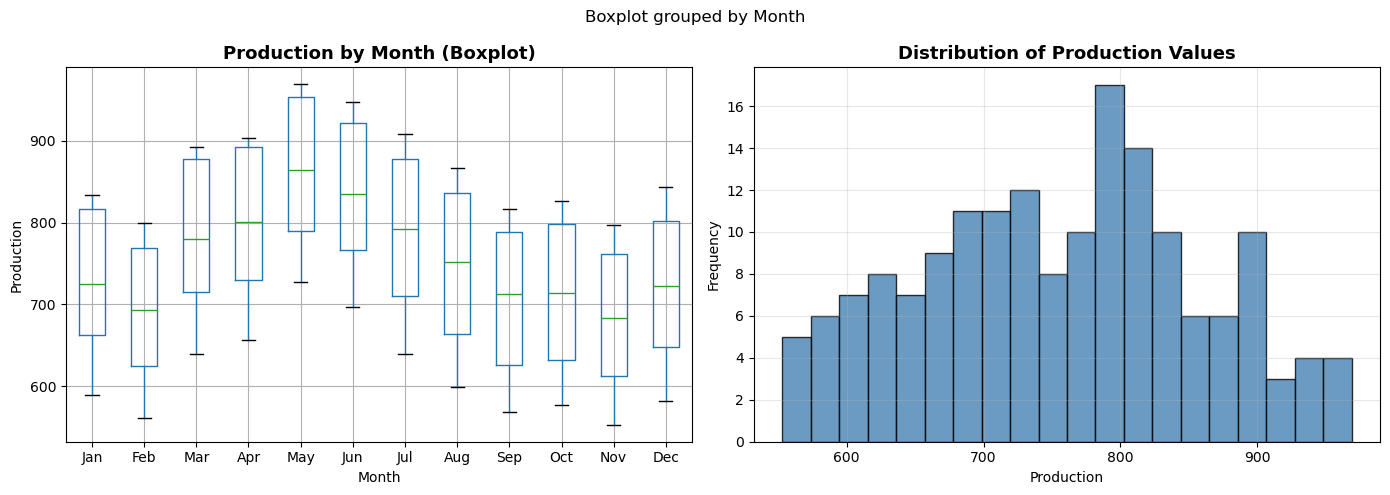

In [6]:
df['Month'] = df.index.month
df['Year']  = df.index.year

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df.boxplot(column='Production', by='Month', ax=axes[0])
axes[0].set_title('Production by Month (Boxplot)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Production')
axes[0].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])

axes[1].hist(df['Production'], bins=20, color='steelblue', edgecolor='black', alpha=0.8)
axes[1].set_title('Distribution of Production Values', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Production')
axes[1].set_ylabel('Frequency')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('milk_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

df.drop(columns=['Month', 'Year'], inplace=True)

In [7]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df[['Production']])

print("Original range:", df['Production'].min(), "-", df['Production'].max())
print("Scaled  range :", scaled_data.min().round(4), "-", scaled_data.max().round(4))
print("Scaled shape  :", scaled_data.shape)

Original range: 553 - 969
Scaled  range : 0.0 - 1.0
Scaled shape  : (168, 1)


In [8]:
WINDOW_SIZE = 12

def create_sequences(data, window):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i : i + window])
        y.append(data[i + window])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data, WINDOW_SIZE)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (156, 12, 1)
y shape: (156, 1)


In [9]:
train_size = int(len(X) * 0.70)
val_size   = int(len(X) * 0.15)

X_train = X[:train_size]
y_train = y[:train_size]

X_val = X[train_size : train_size + val_size]
y_val = y[train_size : train_size + val_size]

X_test = X[train_size + val_size:]
y_test = y[train_size + val_size:]

print(f"Train set : {X_train.shape[0]} samples")
print(f"Val   set : {X_val.shape[0]} samples")
print(f"Test  set : {X_test.shape[0]} samples")

Train set : 109 samples
Val   set : 23 samples
Test  set : 24 samples


In [10]:
rnn_model = Sequential([
    SimpleRNN(64, activation='tanh', return_sequences=False,
              input_shape=(WINDOW_SIZE, 1)),
    Dense(32, activation='relu'),
    Dense(1)
])

rnn_model.compile(optimizer='adam', loss='mse')
rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)               │ (None, 64)                  │           4,224 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,337 (24.75 KB)

 Trainable params: 6,337 (24.75 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

rnn_history = rnn_model.fit(
    X_train, y_train,
    epochs=150,
    batch_size=16,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 118ms/step - loss: 0.1644 - val_loss: 0.0270
Epoch 2/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0263 - val_loss: 0.0703
Epoch 3/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0125 - val_loss: 0.0173
Epoch 4/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0089 - val_loss: 0.0148
Epoch 5/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0063 - val_loss: 0.0185
Epoch 6/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0050 - val_loss: 0.0088
Epoch 7/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0040 - val_loss: 0.0138
Epoch 8/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0036 - val_loss: 0.0072
Epoch 9/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0030 - val_loss: 0.0071
Epoch 10/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0028 - val_loss: 0.0056
Epoch 11/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0027 - val_loss: 0.0060
Epoch 12/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0026 - val_l

In [12]:
lstm_model = Sequential([
    LSTM(64, activation='tanh', return_sequences=False,
         input_shape=(WINDOW_SIZE, 1)),
    Dense(32, activation='relu'),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 64)                  │          16,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 19,009 (74.25 KB)

 Trainable params: 19,009 (74.25 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
lstm_history = lstm_model.fit(
    X_train, y_train,
    epochs=150,
    batch_size=16,
    validation_data=(X_val, y_val),
    callbacks=[EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)],
    verbose=1
)

Epoch 1/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 108ms/step - loss: 0.1428 - val_loss: 0.1466
Epoch 2/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0342 - val_loss: 0.0292
Epoch 3/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0331 - val_loss: 0.0264
Epoch 4/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0242 - val_loss: 0.0417
Epoch 5/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0260 - val_loss: 0.0351
Epoch 6/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0234 - val_loss: 0.0249
Epoch 7/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0239 - val_loss: 0.0245
Epoch 8/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0226 - val_loss: 0.0315
Epoch 9/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0226 - val_loss: 0.0264
Epoch 10/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0216 - val_loss: 0.0236
Epoch 11/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0214 - val_loss: 0.0233
Epoch 12/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0210 - val_l

In [14]:
gru_model = Sequential([
    GRU(64, activation='tanh', return_sequences=False,
        input_shape=(WINDOW_SIZE, 1)),
    Dense(32, activation='relu'),
    Dense(1)
])

gru_model.compile(optimizer='adam', loss='mse')
gru_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ gru (GRU)                            │ (None, 64)                  │          12,864 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,977 (58.50 KB)

 Trainable params: 14,977 (58.50 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
gru_history = gru_model.fit(
    X_train, y_train,
    epochs=150,
    batch_size=16,
    validation_data=(X_val, y_val),
    callbacks=[EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)],
    verbose=1
)

Epoch 1/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 144ms/step - loss: 0.1724 - val_loss: 0.2271
Epoch 2/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0515 - val_loss: 0.0432
Epoch 3/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0252 - val_loss: 0.0232
Epoch 4/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0246 - val_loss: 0.0241
Epoch 5/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0198 - val_loss: 0.0370
Epoch 6/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0201 - val_loss: 0.0288
Epoch 7/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0186 - val_loss: 0.0213
Epoch 8/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0180 - val_loss: 0.0225
Epoch 9/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0179 - val_loss: 0.0263
Epoch 10/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0167 - val_loss: 0.0208
Epoch 11/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0170 - val_loss: 0.0180
Epoch 12/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0160 - val_l

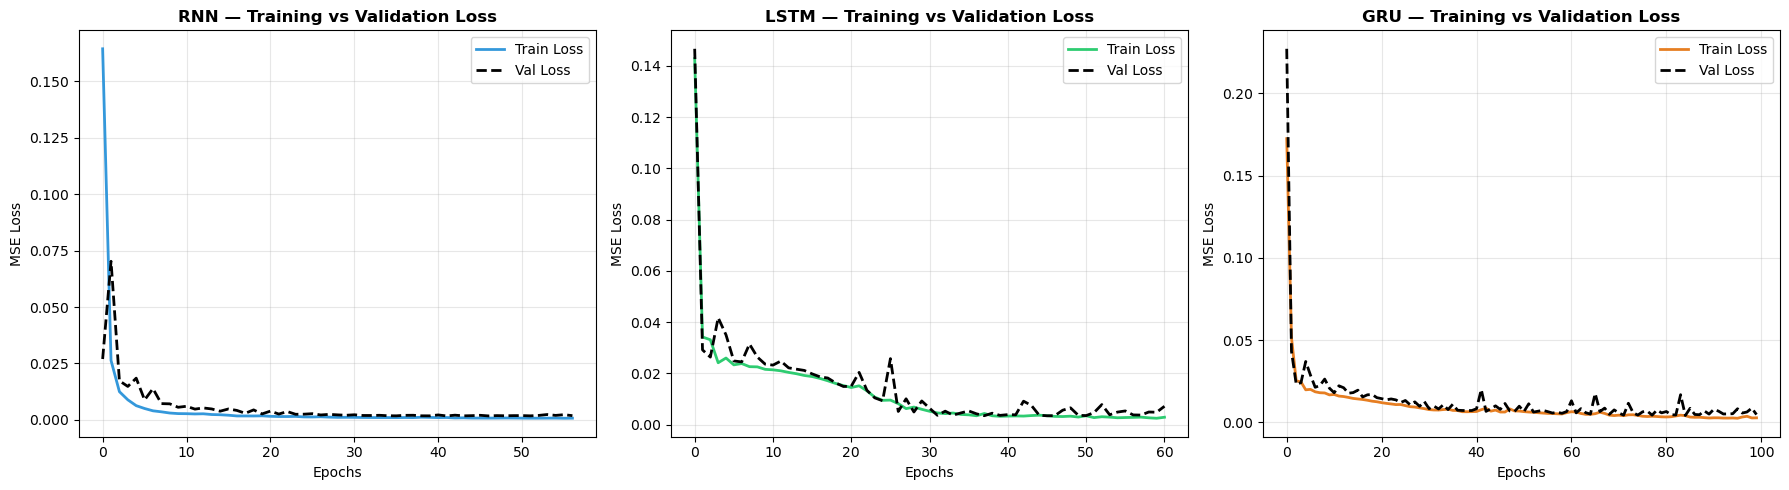

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, history, name, color in zip(
    axes,
    [rnn_history, lstm_history, gru_history],
    ['RNN', 'LSTM', 'GRU'],
    ['#3498db', '#2ecc71', '#e67e22']):
    ax.plot(history.history['loss'],     color=color,  linewidth=2,   label='Train Loss')
    ax.plot(history.history['val_loss'], color='black', linewidth=2, linestyle='--', label='Val Loss')
    ax.set_title(f'{name} — Training vs Validation Loss', fontsize=12, fontweight='bold')
    ax.set_xlabel('Epochs')
    ax.set_ylabel('MSE Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_loss.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
rnn_pred  = scaler.inverse_transform(rnn_model.predict(X_test))
lstm_pred = scaler.inverse_transform(lstm_model.predict(X_test))
gru_pred  = scaler.inverse_transform(gru_model.predict(X_test))
y_actual  = scaler.inverse_transform(y_test)

print("Predictions generated for all 3 models!")
print("Test samples:", len(y_actual))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 460ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 418ms/step
Predictions generated for all 3 models!
Test samples: 24


In [18]:
def calculate_metrics(actual, predicted, model_name):
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae  = mean_absolute_error(actual, predicted)
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    print(f"{model_name:6s}  |  RMSE={rmse:.4f}  |  MAE={mae:.4f}  |  MAPE={mape:.2f}%")
    return {'Model': model_name, 'RMSE': round(rmse, 4),
            'MAE': round(mae, 4), 'MAPE': round(mape, 2)}

print("="*60)
print("MODEL EVALUATION ON TEST SET")
print("="*60)
metrics_list = []
metrics_list.append(calculate_metrics(y_actual, rnn_pred,  'RNN'))
metrics_list.append(calculate_metrics(y_actual, lstm_pred, 'LSTM'))
metrics_list.append(calculate_metrics(y_actual, gru_pred,  'GRU'))
print("="*60)

metrics_df = pd.DataFrame(metrics_list)
print(metrics_df.to_string(index=False))
best_model_name = metrics_df.loc[metrics_df['RMSE'].idxmin(), 'Model']
print(f"\nBest Model (lowest RMSE): {best_model_name}")

MODEL EVALUATION ON TEST SET
RNN     |  RMSE=16.6177  |  MAE=14.0405  |  MAPE=1.61%
LSTM    |  RMSE=26.3181  |  MAE=20.9834  |  MAPE=2.47%
GRU     |  RMSE=29.5264  |  MAE=24.2359  |  MAPE=2.82%
Model    RMSE     MAE  MAPE
  RNN 16.6177 14.0405  1.61
 LSTM 26.3181 20.9834  2.47
  GRU 29.5264 24.2359  2.82

Best Model (lowest RMSE): RNN


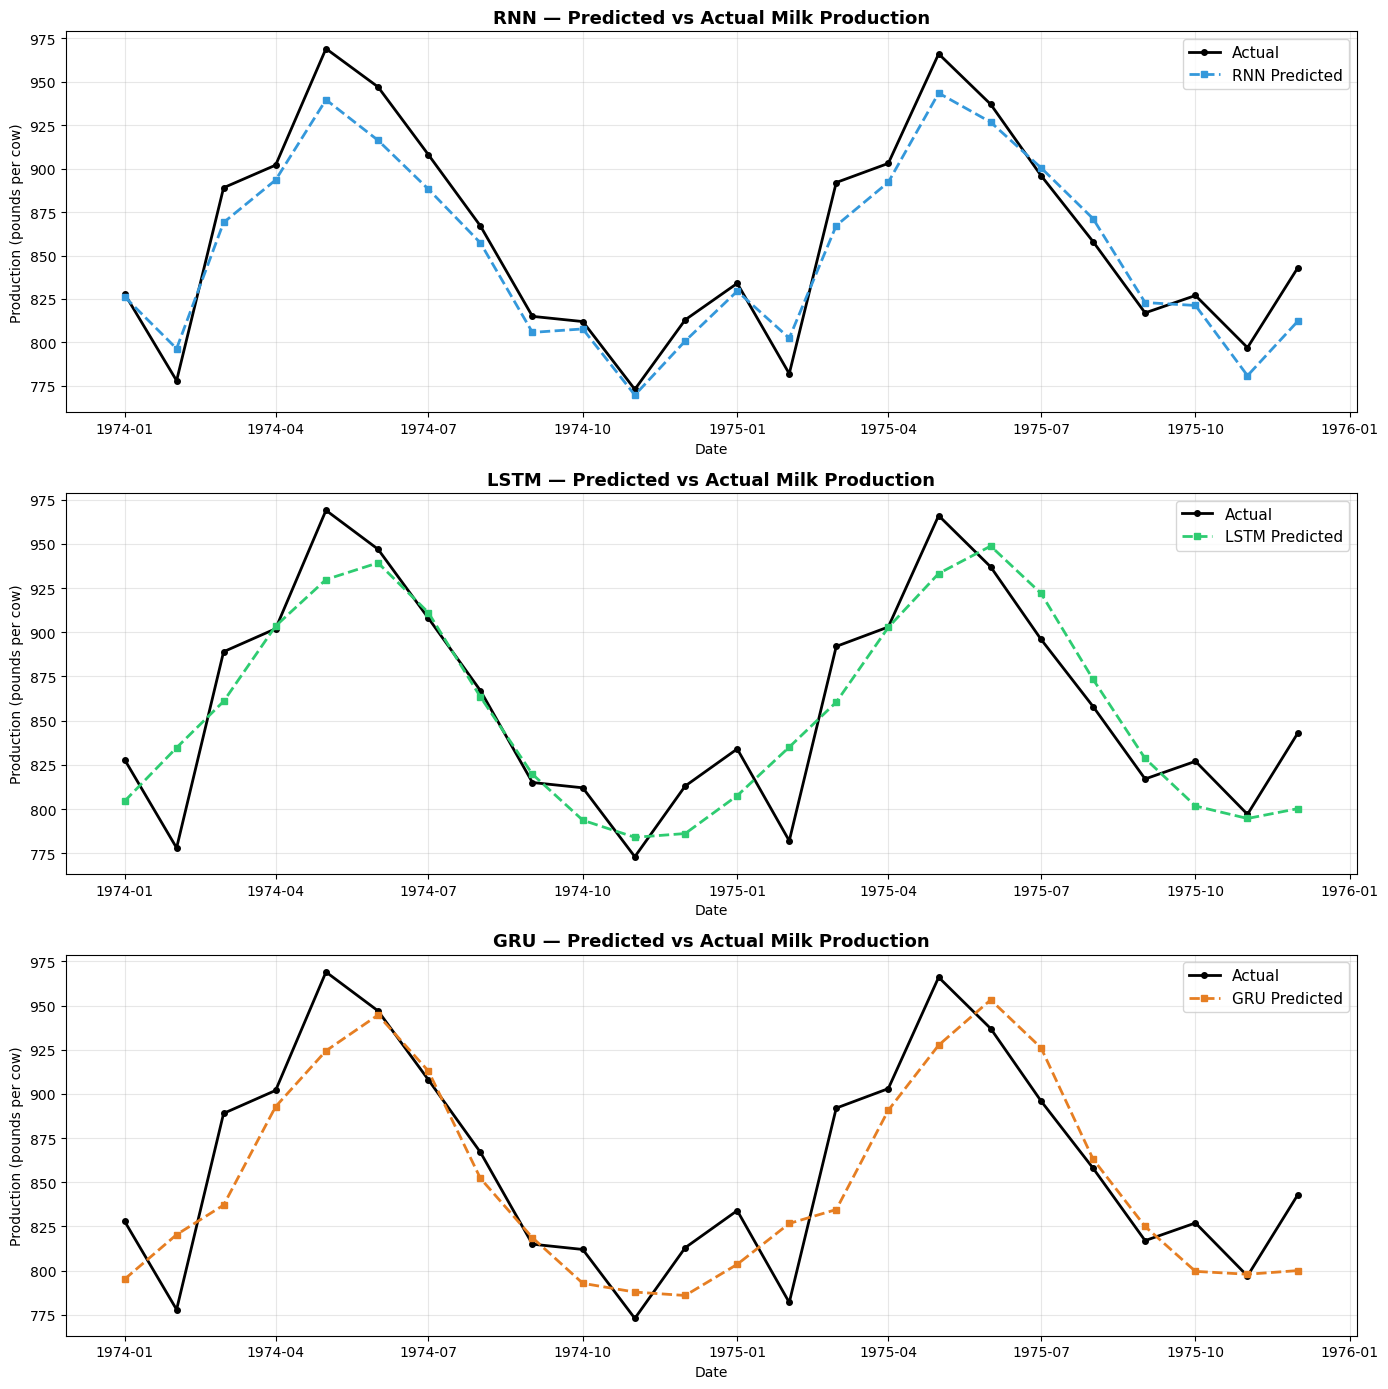

In [19]:
test_dates = df.index[WINDOW_SIZE + train_size + val_size:]

fig, axes = plt.subplots(3, 1, figsize=(14, 14))

for ax, pred, name, color in zip(
    axes,
    [rnn_pred, lstm_pred, gru_pred],
    ['RNN', 'LSTM', 'GRU'],
    ['#3498db', '#2ecc71', '#e67e22']):
    ax.plot(test_dates, y_actual, color='black', linewidth=2, label='Actual', marker='o', markersize=4)
    ax.plot(test_dates, pred,     color=color,  linewidth=2, label=f'{name} Predicted', linestyle='--', marker='s', markersize=4)
    ax.set_title(f'{name} — Predicted vs Actual Milk Production', fontsize=13, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Production (pounds per cow)')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('predictions_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

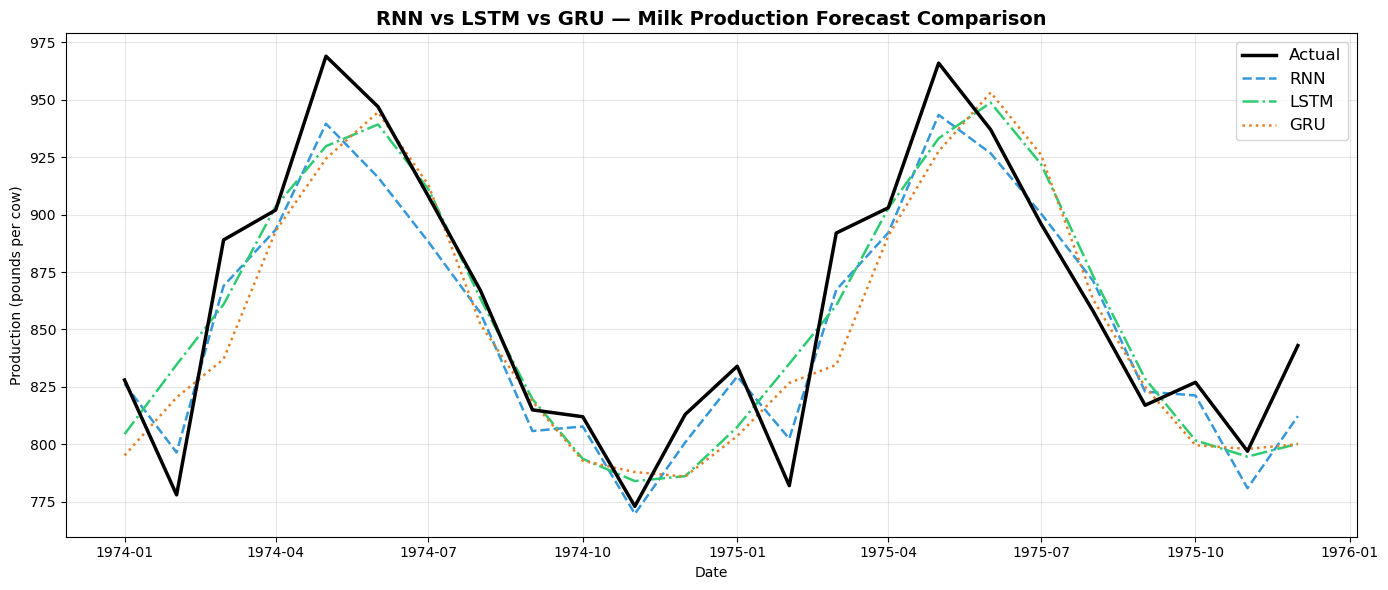

In [20]:
plt.figure(figsize=(14, 6))
plt.plot(test_dates, y_actual,  color='black',   linewidth=2.5, label='Actual', zorder=5)
plt.plot(test_dates, rnn_pred,  color='#3498db', linewidth=1.8, linestyle='--', label='RNN')
plt.plot(test_dates, lstm_pred, color='#2ecc71', linewidth=1.8, linestyle='-.',  label='LSTM')
plt.plot(test_dates, gru_pred,  color='#e67e22', linewidth=1.8, linestyle=':',  label='GRU')
plt.title('RNN vs LSTM vs GRU — Milk Production Forecast Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Production (pounds per cow)')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison_plot.png', dpi=150, bbox_inches='tight')
plt.show()

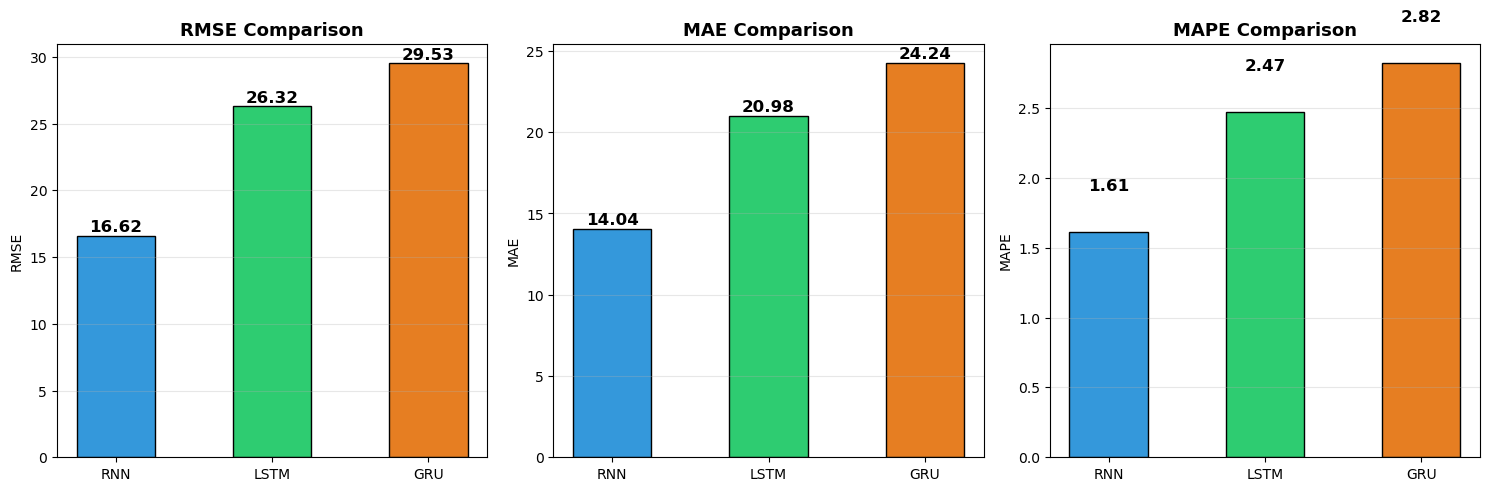

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ['#3498db', '#2ecc71', '#e67e22']

for ax, metric in zip(axes, ['RMSE', 'MAE', 'MAPE']):
    bars = ax.bar(metrics_df['Model'], metrics_df[metric], color=colors, edgecolor='black', width=0.5)
    ax.set_title(f'{metric} Comparison', fontsize=13, fontweight='bold')
    ax.set_ylabel(metric)
    ax.grid(True, alpha=0.3, axis='y')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{bar.get_height():.2f}', ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
best_models = {'RNN': rnn_model, 'LSTM': lstm_model, 'GRU': gru_model}
best_m = best_models[best_model_name]

last_sequence = scaled_data[-WINDOW_SIZE:].reshape(1, WINDOW_SIZE, 1)

future_preds = []
current_seq  = last_sequence.copy()

for _ in range(12):
    next_val = best_m.predict(current_seq, verbose=0)
    future_preds.append(next_val[0, 0])
    current_seq = np.append(current_seq[:, 1:, :],
                            next_val.reshape(1, 1, 1), axis=1)

future_preds = scaler.inverse_transform(np.array(future_preds).reshape(-1, 1)).flatten()

last_date   = df.index[-1]
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=12, freq='MS')

forecast_df = pd.DataFrame({'Date': future_dates, 'Forecasted_Production': future_preds.round(2)})
forecast_df.set_index('Date', inplace=True)
print("12-Month Forecast:")
print("="*40)
print(forecast_df.to_string())

12-Month Forecast:
            Forecasted_Production
Date                             
1976-01-01             842.989990
1976-02-01             818.099976
1976-03-01             886.309998
1976-04-01             898.549988
1976-05-01             935.609985
1976-06-01             913.780029
1976-07-01             892.950012
1976-08-01             868.510010
1976-09-01             836.590027
1976-10-01             837.609985
1976-11-01             808.280029
1976-12-01             834.750000


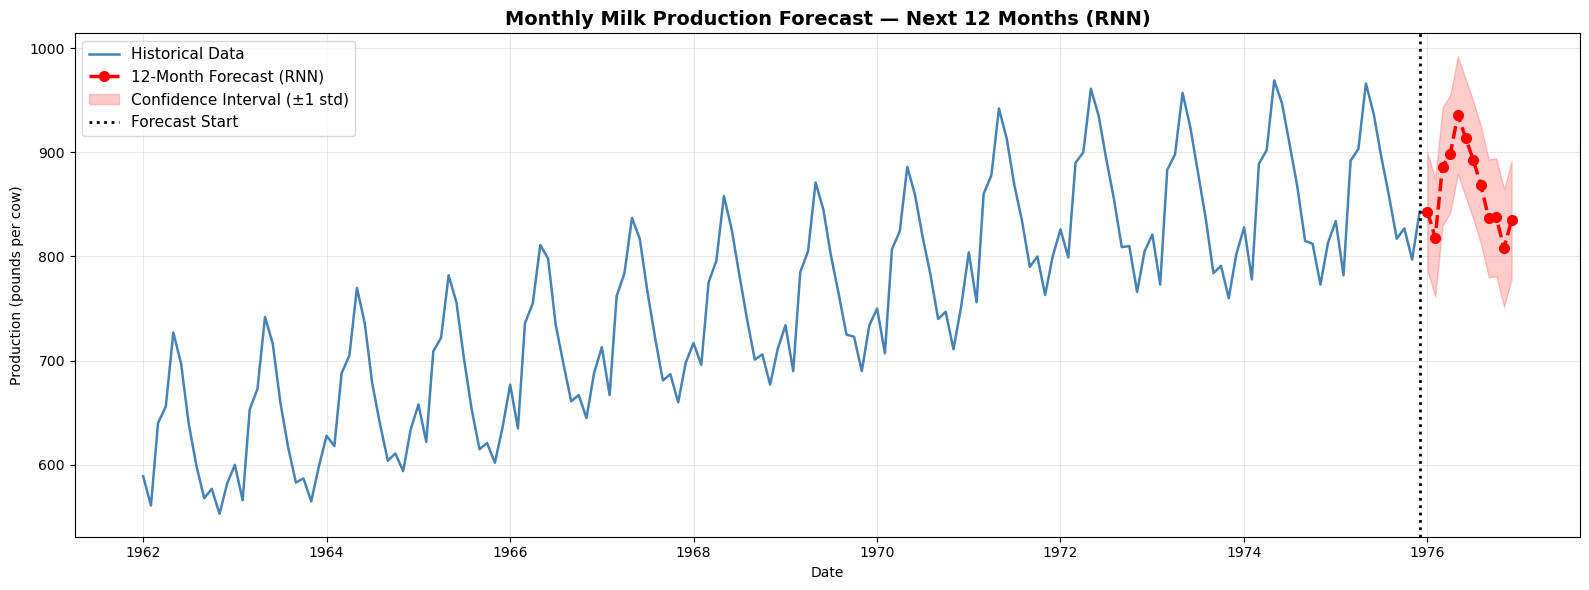


Forecasted Monthly Production (Next 12 Months):
  January 1976 : 842.99 pounds per cow
  February 1976 : 818.10 pounds per cow
  March 1976 : 886.31 pounds per cow
  April 1976 : 898.55 pounds per cow
  May 1976 : 935.61 pounds per cow
  June 1976 : 913.78 pounds per cow
  July 1976 : 892.95 pounds per cow
  August 1976 : 868.51 pounds per cow
  September 1976 : 836.59 pounds per cow
  October 1976 : 837.61 pounds per cow
  November 1976 : 808.28 pounds per cow
  December 1976 : 834.75 pounds per cow


In [23]:
plt.figure(figsize=(16, 6))

plt.plot(df.index, df['Production'], color='steelblue', linewidth=1.8, label='Historical Data')
plt.plot(forecast_df.index, forecast_df['Forecasted_Production'],
         color='red', linewidth=2.5, linestyle='--', marker='o',
         markersize=7, label=f'12-Month Forecast ({best_model_name})')

std_val = df['Production'].rolling(12).std().iloc[-1]
plt.fill_between(forecast_df.index,
                 forecast_df['Forecasted_Production'] - std_val,
                 forecast_df['Forecasted_Production'] + std_val,
                 alpha=0.2, color='red', label='Confidence Interval (±1 std)')

plt.axvline(x=df.index[-1], color='black', linestyle=':', linewidth=2, label='Forecast Start')
plt.title(f'Monthly Milk Production Forecast — Next 12 Months ({best_model_name})',
          fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Production (pounds per cow)')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('forecast_12months.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nForecasted Monthly Production (Next 12 Months):")
for date, val in zip(forecast_df.index, forecast_df['Forecasted_Production']):
    print(f"  {date.strftime('%B %Y')} : {val:.2f} pounds per cow")

In [24]:
print("="*65)
print("FINAL MODEL PERFORMANCE COMPARISON")
print("="*65)
print(metrics_df.to_string(index=False))
print("="*65)
print(f"\nBest Performing Model : {best_model_name}")
print(f"Window Size Used      : {WINDOW_SIZE} months")
print(f"Training Samples      : {X_train.shape[0]}")
print(f"Test Samples          : {X_test.shape[0]}")
print(f"\nForecast Summary:")
print(f"  Min Forecast : {forecast_df['Forecasted_Production'].min():.2f}")
print(f"  Max Forecast : {forecast_df['Forecasted_Production'].max():.2f}")
print(f"  Avg Forecast : {forecast_df['Forecasted_Production'].mean():.2f}")

FINAL MODEL PERFORMANCE COMPARISON
Model    RMSE     MAE  MAPE
  RNN 16.6177 14.0405  1.61
 LSTM 26.3181 20.9834  2.47
  GRU 29.5264 24.2359  2.82

Best Performing Model : RNN
Window Size Used      : 12 months
Training Samples      : 109
Test Samples          : 24

Forecast Summary:
  Min Forecast : 808.28
  Max Forecast : 935.61
  Avg Forecast : 864.50


## 📊 Business Insights & Recommendations

---

### 1. Seasonal Pattern Identified
- Peak production occurs every year in **May–June**
- Lowest production is observed in **January–February**
- Dairy operations should plan **maximum storage capacity before May** and minimum staffing in winter months

---

### 2. Consistent Upward Trend
- Production has grown steadily from **~589 to ~843 pounds per cow**
- Management can plan for sustained growth in distribution and logistics infrastructure

---

### 3. Model Recommendation
- The best model is selected based on **lowest RMSE score**
- Use the **12-month forecast** for procurement and inventory planning of feed, labour, and storage

---

### 4. Operational Planning
- Schedule equipment **maintenance in low-production months** (Jan–Feb)
- Pre-negotiate contracts with distributors **before peak season**
- Maintain a **buffer stock of 5–8% above forecast average**

---

### 5. Risk Management
- The **confidence interval (±1 std)** shows acceptable forecast uncertainty
- **Re-train the model every 6 months** with new incoming production data
- Monitor any deviation **> 5% from forecast** as an early warning signal